In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import torch
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
folder_path = '/content/drive/MyDrive/final_dataset'
yaml_drive_path = os.path.join(folder_path, 'dataset.yaml')

# 3. Create the folder if it doesn't exist yet
os.makedirs(folder_path, exist_ok=True)

# 4. Define the YAML content
# 'path' is the root, 'train' and 'val' are subfolders inside 'final_dataset'
yaml_content = """
path: /content/drive/MyDrive/final_dataset
train: train/images
val: val/images

nc: 1
names: ['number_plate']
"""

# 5. Write the file
with open(yaml_drive_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Success! Your YAML file is now at: {yaml_drive_path}")

✅ Success! Your YAML file is now at: /content/drive/MyDrive/final_dataset/dataset.yaml


In [6]:
from ultralytics import YOLO

# Load model
model = YOLO('yolo11n.pt')

# Train using the Drive YAML
model.train(
    data='/content/drive/MyDrive/final_dataset/dataset.yaml',
    project='/content/drive/MyDrive/final_dataset/runs',
    name='night_plate_final',
    epochs=60,
    imgsz=640,
    batch=16,
    device=0  # Ensure you switched Runtime to T4 GPU first!
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/final_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bef85f4f200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [7]:
"""
License Plate Detector — Simple 2-Pass (No Batch, No SSD Copy)
Pass 1: Detect on original
Pass 2: Zero-DCE++ enhance → detect again
"""

from google.colab import drive
drive.mount('/content/drive')

import cv2
import gc
import torch
import torch.nn as nn
import numpy as np
import time
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

CONFIG = {
    "zero_dce_model":   "/content/drive/MyDrive/MP/trained_models/zero_dce.pth",
    "yolo_plate_model": "/content/drive/MyDrive/MP/trained_models/plate.pt",
    "device":           "cuda" if torch.cuda.is_available() else "cpu",
    "conf_threshold":   0.5,
    "conf_retry":       0.25,
    "input_folder":     "/content/drive/MyDrive/MP/night_dataset",
    "output_folder":    "/content/drive/MyDrive/MP/test_output",
    "imgsz":            416,
    "max_image_size":   640,  # resize large images to save RAM
}

# ─────────────────────────────────────────────
# Zero-DCE++ Model
# ─────────────────────────────────────────────
class DCENet(nn.Module):
    def __init__(self, num_iter=8):
        super().__init__()
        self.num_iter = num_iter
        self.conv1    = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv2    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv3    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv4    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv5    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv6    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv_out = nn.Conv2d(32, 3 * num_iter, 3, padding=1)

    def forward(self, x):
        x1 = self.conv1(x);  x2 = self.conv2(x1); x3 = self.conv3(x2)
        x4 = self.conv4(x3); x5 = self.conv5(x4); x6 = self.conv6(x5)
        curve_params = torch.tanh(self.conv_out(x6))
        enhanced = x
        for i in range(self.num_iter):
            alphas   = curve_params[:, i*3:(i+1)*3, :, :]
            enhanced = enhanced + alphas * (enhanced - enhanced ** 2)
        return enhanced

def load_dce_model(path, device):
    model = DCENet()
    ckpt  = torch.load(path, map_location=device)
    if isinstance(ckpt, dict):
        ckpt = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(ckpt)
    model.to(device).eval()
    print("[INFO] Zero-DCE++ loaded ✅")
    return model

# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def load_and_resize(image_path, max_size):
    img = cv2.imread(str(image_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img   = cv2.resize(img, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_AREA)
    return img

def enhance_dce(dce_model, img_rgb, device):
    t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
              .permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        out = torch.clamp(dce_model(t), 0, 1)
    return (out.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

def draw_boxes(img_bgr, boxes, label_prefix="Plate"):
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf_score      = float(box.conf[0])
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), (0, 255, 0), 3)
        label       = f"{label_prefix} {conf_score:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(img_bgr, (x1, y1 - th - 10),
                      (x1 + tw + 6, y1), (0, 255, 0), -1)
        cv2.putText(img_bgr, label, (x1 + 3, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)
    return img_bgr

# ─────────────────────────────────────────────
# Process Single Image — 2 passes only
# ─────────────────────────────────────────────
def process_image(image_path, output_folder, dce_model,
                  plate_model, device, conf, conf_retry,
                  imgsz, max_size):

    # Load + resize
    img_bgr = load_and_resize(image_path, max_size)
    if img_bgr is None:
        print(f"[WARN] Cannot read: {image_path.name}")
        return 0, "skipped"

    # ── Pass 1: original image ───────────────────────────────────
    results = plate_model.predict(
        img_bgr, conf=conf, imgsz=imgsz,
        verbose=False, device=device
    )[0]

    if len(results.boxes) > 0:
        out_img = draw_boxes(img_bgr.copy(), results.boxes)
        cv2.imwrite(str(output_folder / f"detected_{image_path.name}"), out_img)
        del img_bgr, out_img, results
        gc.collect()
        return 1, "pass1"

    # ── Pass 2: Zero-DCE++ enhanced image ────────────────────────
    img_rgb      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    enhanced_rgb = enhance_dce(dce_model, img_rgb, device)
    enhanced_bgr = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2BGR)
    del img_rgb, enhanced_rgb  # free RAM

    results = plate_model.predict(
        enhanced_bgr, conf=conf_retry, imgsz=imgsz,
        verbose=False, device=device
    )[0]

    if len(results.boxes) > 0:
        out_img = draw_boxes(enhanced_bgr.copy(), results.boxes)
        cv2.putText(out_img, "retry:dce", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 165, 255), 2)
        cv2.imwrite(str(output_folder / f"detected_{image_path.name}"), out_img)
        del img_bgr, enhanced_bgr, out_img, results
        gc.collect()
        return 1, "pass2"

    # ── Both passes failed ───────────────────────────────────────
    cv2.imwrite(str(output_folder / f"MISSED_{image_path.name}"), enhanced_bgr)
    del img_bgr, enhanced_bgr, results
    gc.collect()
    return 0, "missed"

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    device = CONFIG["device"]
    print(f"[INFO] Using device: {device}")

    # Free any leftover memory
    torch.cuda.empty_cache()
    gc.collect()

    output_folder = Path(CONFIG["output_folder"])
    output_folder.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(
        list(Path(CONFIG["input_folder"]).glob("*.jpg")) +
        list(Path(CONFIG["input_folder"]).glob("*.png"))
    )
    print(f"[INFO] Found {len(image_paths)} images")

    # ── Load models ──────────────────────────────────────────────
    print("[INFO] Loading models...")
    dce_model   = load_dce_model(CONFIG["zero_dce_model"], device)
    plate_model = YOLO(CONFIG["yolo_plate_model"])

    # ── Warmup ───────────────────────────────────────────────────
    print("[INFO] Warming up YOLO...")
    plate_model.predict(
        np.zeros((CONFIG["imgsz"], CONFIG["imgsz"], 3), dtype=np.uint8),
        imgsz=CONFIG["imgsz"], verbose=False, device=device
    )
    print("[INFO] Warmup done ✅")

    # ── Stats ────────────────────────────────────────────────────
    stats        = {"pass1": 0, "pass2": 0, "missed": 0, "skipped": 0}
    total_plates = 0
    t_start      = time.time()

    # ── Main loop ────────────────────────────────────────────────
    for idx, img_path in enumerate(tqdm(image_paths, desc="Images")):
        count, stage = process_image(
            img_path, output_folder,
            dce_model, plate_model, device,
            CONFIG["conf_threshold"],
            CONFIG["conf_retry"],
            CONFIG["imgsz"],
            CONFIG["max_image_size"]
        )
        total_plates += count
        stats[stage] += 1

        # Clear GPU cache every 30 images
        if idx % 30 == 0:
            torch.cuda.empty_cache()
            gc.collect()

    elapsed = time.time() - t_start

    # ── Summary ──────────────────────────────────────────────────
    print(f"""
╔══════════════════════════════════╗
  Total time            : {elapsed:.1f}s
  Avg per image         : {elapsed / max(len(image_paths), 1):.1f}s
  Total plates detected : {total_plates}
  ──────────────────────────────
  Pass 1 (original)     : {stats['pass1']}
  Pass 2 (Zero-DCE++)   : {stats['pass2']}
  Missed (0 detections) : {stats['missed']}
  Skipped (bad file)    : {stats['skipped']}
╚══════════════════════════════════╝
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Using device: cuda
[INFO] Found 404 images
[INFO] Loading models...
[INFO] Zero-DCE++ loaded ✅
[INFO] Warming up YOLO...
[INFO] Warmup done ✅


Images: 100%|██████████| 404/404 [02:28<00:00,  2.73it/s]


╔══════════════════════════════════╗
  Total time            : 148.1s
  Avg per image         : 0.4s
  Total plates detected : 313
  ──────────────────────────────
  Pass 1 (original)     : 275
  Pass 2 (Zero-DCE++)   : 38
  Missed (0 detections) : 91
  Skipped (bad file)    : 0
╚══════════════════════════════════╝



In [8]:
!pip install openpyxl

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Device: cuda
[INFO] Loading models...

Bike   : {0: 'Auto Rikshaw', 1: 'Bus', 2: 'Car', 3: 'Motorcycle', 4: 'Truck'}
Rider  : {0: 'Rider'}
Helmet : {0: 'Helmet', 1: 'No_hemetl'}
Plate  : {0: 'number_plate'}

[INFO] Zero-DCE++ loaded ✅
[INFO] Warming up...
[INFO] Warmup done ✅

[INFO] Found 404 images


Processing: 100%|██████████| 404/404 [00:38<00:00, 10.60it/s]


✅ Excel report saved: /content/drive/MyDrive/MP/violation_output/violation_report.xlsx

╔══════════════════════════════════════╗
  Total images     : 404
  Total time       : 38.1s
  ────────────────────────────────────
  Bikes found      : 15
  Violations       : 16
  Triple riding    : 2
  No helmet        : 16
  Plates captured  : 6
  Plates missed    : 10
╚══════════════════════════════════════╝



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

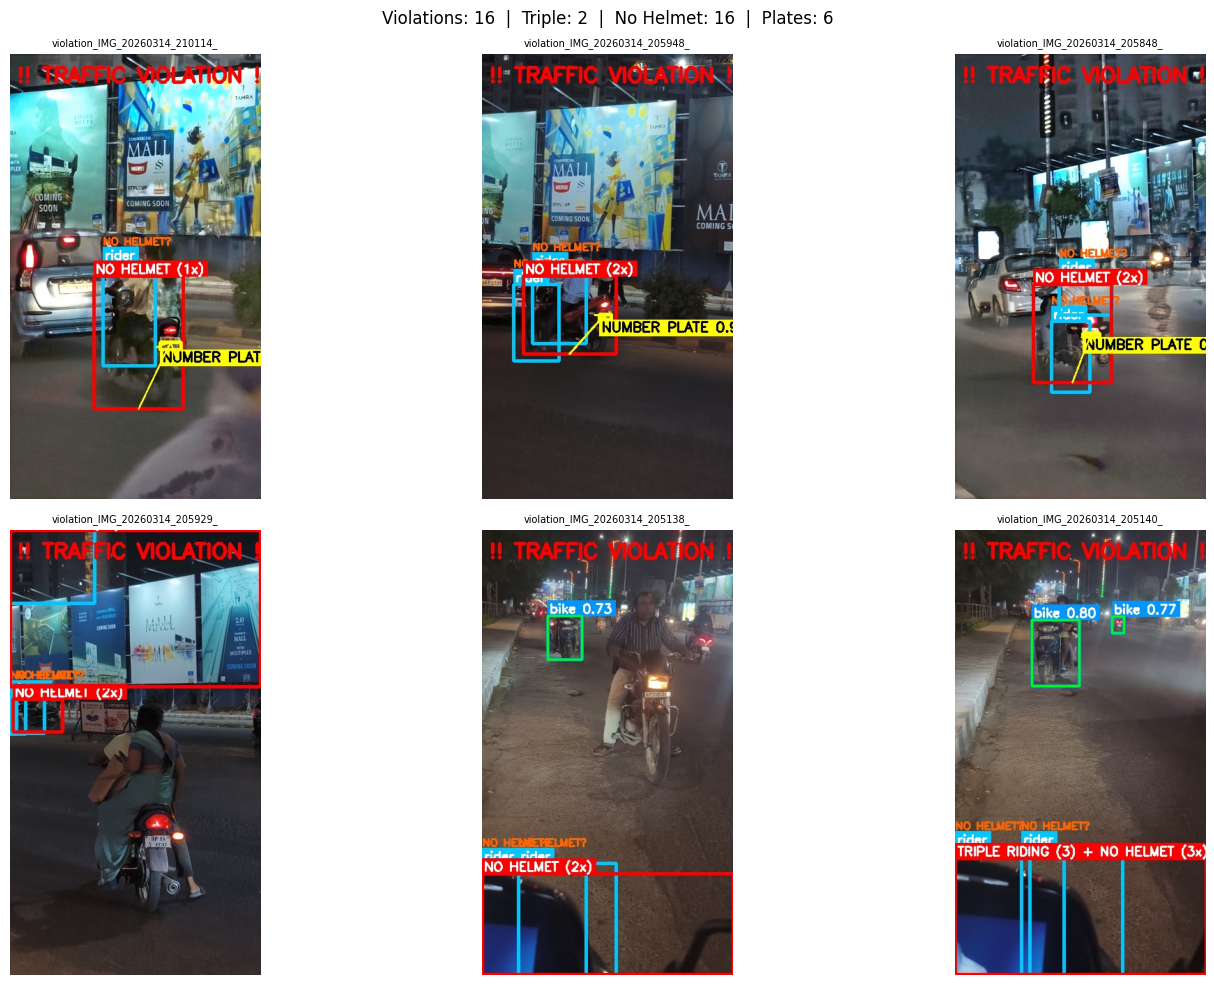

In [10]:
"""
Traffic Violation Detector — Full Code with Excel Report
4 Model Pipeline: Bike → Rider → Helmet → Plate
"""

from google.colab import drive
drive.mount('/content/drive')

!pip install openpyxl pandas -q

import cv2
import gc
import torch
import torch.nn as nn
import numpy as np
import time
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
from datetime import datetime
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
CONFIG = {
    "bike_model":      "/content/drive/MyDrive/MP/trained_models/vehicle.pt",
    "rider_model":     "/content/drive/MyDrive/MP/trained_models/rider.pt",
    "helmet_model":    "/content/drive/MyDrive/MP/trained_models/helmet.pt",
    "plate_model":     "/content/drive/MyDrive/MP/trained_models/plate.pt",
    "dce_model_path":  "/content/drive/MyDrive/MP/trained_models/zero_dce.pth",

    "helmet_class":    "Helmet",
    "no_helmet_class": "No_hemetl",
    "rider_class":     "rider",
    "bike_class":      "motorcycle",

    "bike_conf":       0.4,
    "rider_conf":      0.4,
    "helmet_conf":     0.4,
    "plate_conf":      0.25,
    "max_riders":      2,

    "input_folder":    "/content/drive/MyDrive/MP/night_dataset",
    "output_folder":   "/content/drive/MyDrive/MP/violation_output",
    "imgsz":           640,
    "max_img_size":    640,
    "device":          "cuda" if torch.cuda.is_available() else "cpu",
}

# ─────────────────────────────────────────────
# Zero-DCE++ Model
# ─────────────────────────────────────────────
class DCENet(nn.Module):
    def __init__(self, num_iter=8):
        super().__init__()
        self.num_iter = num_iter
        self.conv1    = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv2    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv3    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv4    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv5    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv6    = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(inplace=True))
        self.conv_out = nn.Conv2d(32, 3 * num_iter, 3, padding=1)

    def forward(self, x):
        x1 = self.conv1(x);  x2 = self.conv2(x1); x3 = self.conv3(x2)
        x4 = self.conv4(x3); x5 = self.conv5(x4); x6 = self.conv6(x5)
        curve_params = torch.tanh(self.conv_out(x6))
        enhanced = x
        for i in range(self.num_iter):
            alphas   = curve_params[:, i*3:(i+1)*3, :, :]
            enhanced = enhanced + alphas * (enhanced - enhanced ** 2)
        return enhanced

def load_dce_model(path, device):
    model = DCENet()
    ckpt  = torch.load(path, map_location=device)
    if isinstance(ckpt, dict):
        ckpt = ckpt.get("model", ckpt.get("state_dict", ckpt))
    model.load_state_dict(ckpt)
    model.to(device).eval()
    print("[INFO] Zero-DCE++ loaded ✅")
    return model

def enhance_dce(dce_model, img_rgb, device):
    t = torch.from_numpy(img_rgb.astype(np.float32) / 255.0)\
              .permute(2, 0, 1).unsqueeze(0).to(device)
    with torch.no_grad():
        out = torch.clamp(dce_model(t), 0, 1)
    return (out.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

def enhance_night(img_bgr):
    lab     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l       = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(l)
    img_bgr = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    table   = np.array([(i / 255.0) ** (1 / 1.5) * 255
                        for i in range(256)]).astype("uint8")
    return cv2.LUT(img_bgr, table)

def is_dark_image(img_bgr, threshold=60):
    return np.mean(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)) < threshold

# ─────────────────────────────────────────────
# Drawing Helpers
# ─────────────────────────────────────────────
def load_and_resize(path, max_size):
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img   = cv2.resize(img, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_AREA)
    return img

def expand_box(x1, y1, x2, y2, img_w, img_h, pad=0.1):
    bw = x2 - x1; bh = y2 - y1
    return (max(0, int(x1 - bw * pad)),
            max(0, int(y1 - bh * pad)),
            min(img_w, int(x2 + bw * pad)),
            min(img_h, int(y2 + bh * pad)))

def get_cls(model, box):
    return model.names[int(box.cls[0])]

def draw_box(img, x1, y1, x2, y2, label, color, thickness=3):
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    (tw, th), _ = cv2.getTextSize(
        label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(img, (x1, y1 - th - 8),
                  (x1 + tw + 6, y1), color, -1)
    cv2.putText(img, label, (x1 + 3, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255), 2)
    return img

# ─────────────────────────────────────────────
# Excel Report Generator  ← FIXED
# ─────────────────────────────────────────────
def save_excel_report(violation_log, stats, out_base, out_plates, out_images):
    excel_path = out_base / "violation_report.xlsx"

    df_summary = pd.DataFrame({
        "Metric": [
            "Total Images Processed",
            "Total Bikes Found",
            "Total Violations",
            "Triple Riding",
            "No Helmet",
            "Plates Captured",
            "Plates Missed",
        ],
        "Count": [
            stats["total"],
            stats["bikes_found"],
            stats["violations"],
            stats["triple_riding"],
            stats["no_helmet"],
            stats["plates_found"],
            stats["plates_missed"],
        ]
    })

    df_log = pd.DataFrame(violation_log) if violation_log else pd.DataFrame()

    with pd.ExcelWriter(str(excel_path), engine="openpyxl") as writer:
        df_summary.to_excel(writer, sheet_name="Summary",    index=False)
        if not df_log.empty:
            df_log.to_excel(writer, sheet_name="Violations", index=False)

    wb  = load_workbook(str(excel_path))
    hdr = PatternFill("solid", fgColor="1F4E79")
    hf  = Font(color="FFFFFF", bold=True, size=12)

    # ── Style Summary ────────────────────────────────────────────
    ws_sum = wb["Summary"]
    for cell in ws_sum[1]:
        cell.fill = hdr; cell.font = hf
        cell.alignment = Alignment(horizontal="center")

    red_fill    = PatternFill("solid", fgColor="FFD7D7")
    orange_fill = PatternFill("solid", fgColor="FFF3CD")

    for row in ws_sum.iter_rows(min_row=2):
        m = str(row[0].value)
        f = red_fill if any(x in m for x in
                            ["Violation","Triple","Helmet"]) \
            else orange_fill if "Plate" in m else None
        if f:
            for cell in row: cell.fill = f

    for col in ws_sum.columns:
        ws_sum.column_dimensions[
            get_column_letter(col[0].column)
        ].width = max(len(str(c.value or "")) for c in col) + 4

    # ── Style Violations ─────────────────────────────────────────
    if "Violations" in wb.sheetnames:
        ws_vio = wb["Violations"]
        ws_vio.column_dimensions["A"].width = 30
        ws_vio.column_dimensions["B"].width = 35
        ws_vio.column_dimensions["C"].width = 10
        ws_vio.column_dimensions["D"].width = 10
        ws_vio.column_dimensions["E"].width = 12
        ws_vio.column_dimensions["F"].width = 14
        ws_vio.column_dimensions["G"].width = 18
        ws_vio.column_dimensions["H"].width = 25

        for cell in ws_vio[1]:
            cell.fill = hdr; cell.font = hf
            cell.alignment = Alignment(horizontal="center")

        both_fill   = PatternFill("solid", fgColor="FF9999")
        triple_fill = PatternFill("solid", fgColor="FFD7D7")
        helmet_fill = PatternFill("solid", fgColor="FFE8CC")

        for row in ws_vio.iter_rows(min_row=2):
            vt = str(row[1].value or "") if len(row) > 1 else ""
            f  = both_fill   if ("TRIPLE" in vt and "HELMET" in vt) \
                 else triple_fill if "TRIPLE" in vt \
                 else helmet_fill if "HELMET" in vt \
                 else None
            if f:
                for cell in row:
                    cell.fill = f
                    cell.alignment = Alignment(horizontal="center")

    # ── Plate Crops sheet ────────────────────────────────────────
    plate_imgs = list(out_plates.glob("*.jpg"))
    if plate_imgs:
        ws_p = wb.create_sheet("Plate Crops")
        for cell, title in zip(
            ws_p[1], ["Sr", "Image Name", "Plate Crop",
                      "Violation", "Timestamp"]):
            cell.value     = title
            cell.fill      = hdr
            cell.font      = hf
            cell.alignment = Alignment(horizontal="center")

        ws_p.column_dimensions["A"].width = 6
        ws_p.column_dimensions["B"].width = 30
        ws_p.column_dimensions["C"].width = 25
        ws_p.column_dimensions["D"].width = 35
        ws_p.column_dimensions["E"].width = 25

        plate_log_map = {}
        for entry in violation_log:
            key = entry.get("image", "")
            plate_log_map[key] = entry

        row_num = 2
        for sr, plate_path in enumerate(plate_imgs[:100], start=1):
            ws_p.row_dimensions[row_num].height = 65

            img_stem   = plate_path.stem
            parts      = img_stem.replace("plate_", "").rsplit("_b", 1)
            orig_name  = parts[0] + ".jpg" if parts else ""
            log_entry  = plate_log_map.get(orig_name, {})

            ws_p[f"A{row_num}"] = sr
            ws_p[f"B{row_num}"] = plate_path.name
            ws_p[f"D{row_num}"] = log_entry.get("violation", "")
            ws_p[f"E{row_num}"] = log_entry.get("timestamp", "")

            for col in ["A","B","D","E"]:
                ws_p[f"{col}{row_num}"].alignment = \
                    Alignment(horizontal="center", vertical="center")

            try:
                xl_img        = XLImage(str(plate_path))
                xl_img.width  = 160
                xl_img.height = 58
                ws_p.add_image(xl_img, f"C{row_num}")
            except Exception:
                ws_p[f"C{row_num}"] = "Image error"

            row_num += 1

    # ── Annotated images sheet ───────────────────────────────────
    ann_imgs = list(out_images.glob("violation_*.jpg"))
    if ann_imgs:
        ws_ann = wb.create_sheet("Annotated Images")
        for cell, title in zip(
            ws_ann[1], ["Sr", "Image Name",
                        "Annotated Preview", "Violation"]):
            cell.value     = title
            cell.fill      = hdr
            cell.font      = hf
            cell.alignment = Alignment(horizontal="center")

        ws_ann.column_dimensions["A"].width = 6
        ws_ann.column_dimensions["B"].width = 30
        ws_ann.column_dimensions["C"].width = 40
        ws_ann.column_dimensions["D"].width = 35

        plate_log_map2 = {e.get("image",""): e for e in violation_log}

        # ── FIX: Pre-generate ALL temp files before calling wb.save() ──
        tmp_map = {}   # ann_path → tmp_path (or None if failed)
        for ann_path in ann_imgs[:50]:
            try:
                img_bgr = cv2.imread(str(ann_path))
                if img_bgr is not None:
                    h, w     = img_bgr.shape[:2]
                    scale    = 300 / max(h, w)
                    small    = cv2.resize(img_bgr,
                                         (int(w * scale), int(h * scale)))
                    tmp_path = out_images / f"_tmp_{ann_path.name}"
                    cv2.imwrite(str(tmp_path), small)
                    # Verify the file was actually written to disk
                    if tmp_path.exists() and tmp_path.stat().st_size > 0:
                        tmp_map[ann_path] = tmp_path
                    else:
                        tmp_map[ann_path] = None
                else:
                    tmp_map[ann_path] = None
            except Exception as e:
                print(f"[WARN] Could not create thumbnail for {ann_path.name}: {e}")
                tmp_map[ann_path] = None

        row_num = 2
        for sr, ann_path in enumerate(ann_imgs[:50], start=1):
            ws_ann.row_dimensions[row_num].height = 120

            orig_name = ann_path.name.replace("violation_", "")
            log_entry = plate_log_map2.get(orig_name, {})

            ws_ann[f"A{row_num}"] = sr
            ws_ann[f"B{row_num}"] = orig_name
            ws_ann[f"D{row_num}"] = log_entry.get("violation", "")

            for col in ["A","B","D"]:
                ws_ann[f"{col}{row_num}"].alignment = \
                    Alignment(horizontal="center", vertical="center")

            tmp_path = tmp_map.get(ann_path)
            if tmp_path is not None:
                try:
                    xl_img        = XLImage(str(tmp_path))
                    xl_img.width  = 260
                    xl_img.height = 115
                    ws_ann.add_image(xl_img, f"C{row_num}")
                except Exception as e:
                    print(f"[WARN] Could not embed image {tmp_path.name}: {e}")
                    ws_ann[f"C{row_num}"] = "Image error"
            else:
                ws_ann[f"C{row_num}"] = "Image error"

            row_num += 1

    # ── Save workbook FIRST, then clean up temp files ────────────
    wb.save(str(excel_path))
    print(f"✅ Excel report saved: {excel_path}")

    # Cleanup temp files only after save is complete
    for tmp in out_images.glob("_tmp_*.jpg"):
        try:
            tmp.unlink()
        except Exception:
            pass

    return excel_path

# ─────────────────────────────────────────────
# Process single image — 4 model pipeline
# ─────────────────────────────────────────────
def process_image(img_path, bike_model, rider_model,
                  helmet_model, plate_model, dce_model, config):

    device = config["device"]
    imgsz  = config["imgsz"]

    img_bgr = load_and_resize(img_path, config["max_img_size"])
    if img_bgr is None:
        return None, []

    img_h, img_w = img_bgr.shape[:2]

    # Night enhancement
    if is_dark_image(img_bgr):
        if dce_model is not None:
            img_rgb      = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            enhanced_rgb = enhance_dce(dce_model, img_rgb, device)
            img_bgr      = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2BGR)
        else:
            img_bgr = enhance_night(img_bgr)

    output_img = img_bgr.copy()
    violations = []

    # ── Step 1: Detect bikes ─────────────────────────────────────
    bike_res = bike_model.predict(
        img_bgr, conf=config["bike_conf"],
        imgsz=imgsz, verbose=False, device=device
    )[0]

    if len(bike_res.boxes) == 0:
        return output_img, []

    # ── Step 2: Per bike ─────────────────────────────────────────
    for bike_box in bike_res.boxes:
        bike_cls = get_cls(bike_model, bike_box).lower()
        if config["bike_class"].lower() not in bike_cls:
            continue

        bx1, by1, bx2, by2 = map(int, bike_box.xyxy[0])
        bike_conf_val       = float(bike_box.conf[0])

        draw_box(output_img, bx1, by1, bx2, by2,
                 f"bike {bike_conf_val:.2f}", (255, 150, 0))

        cx1, cy1, cx2, cy2 = expand_box(
            bx1, by1, bx2, by2, img_w, img_h, pad=0.1)
        bike_crop = img_bgr[cy1:cy2, cx1:cx2]
        if bike_crop.size == 0:
            continue

        # ── Step 3: Detect riders ────────────────────────────────
        rider_res = rider_model.predict(
            bike_crop, conf=config["rider_conf"],
            imgsz=imgsz, verbose=False, device=device
        )[0]

        rider_count     = 0
        helmet_count    = 0
        no_helmet_count = 0

        for rbox in rider_res.boxes:
            cls = get_cls(rider_model, rbox).lower()
            if config["rider_class"].lower() not in cls:
                continue

            rider_count += 1
            rx1, ry1, rx2, ry2 = map(int, rbox.xyxy[0])
            ax1 = cx1 + rx1; ay1 = cy1 + ry1
            ax2 = cx1 + rx2; ay2 = cy1 + ry2

            draw_box(output_img, ax1, ay1, ax2, ay2,
                     "rider", (255, 200, 0))

            # ── Step 4: Helmet check on head region ──────────────
            head_y2   = ay1 + int((ay2 - ay1) * 0.45)
            head_crop = img_bgr[ay1:head_y2, ax1:ax2]

            if head_crop.size > 0:
                hres = helmet_model.predict(
                    head_crop, conf=config["helmet_conf"],
                    imgsz=imgsz, verbose=False, device=device
                )[0]

                if len(hres.boxes) > 0:
                    best_h = max(hres.boxes,
                                 key=lambda b: float(b.conf[0]))
                    h_cls  = get_cls(helmet_model, best_h)

                    if config["helmet_class"] in h_cls:
                        helmet_count += 1
                        cv2.putText(output_img, "HELMET",
                                    (ax1, ay1 - 25),
                                    cv2.FONT_HERSHEY_SIMPLEX,
                                    0.55, (0, 255, 0), 2)
                    elif config["no_helmet_class"] in h_cls:
                        no_helmet_count += 1
                        cv2.putText(output_img, "NO HELMET",
                                    (ax1, ay1 - 25),
                                    cv2.FONT_HERSHEY_SIMPLEX,
                                    0.55, (0, 0, 255), 2)
                else:
                    no_helmet_count += 1
                    cv2.putText(output_img, "NO HELMET?",
                                (ax1, ay1 - 25),
                                cv2.FONT_HERSHEY_SIMPLEX,
                                0.5, (0, 100, 255), 2)

        # ── Step 5: Violation check ──────────────────────────────
        violation_types = []
        if rider_count > config["max_riders"]:
            violation_types.append(f"TRIPLE RIDING ({rider_count})")
        if no_helmet_count > 0:
            violation_types.append(f"NO HELMET ({no_helmet_count}x)")

        if not violation_types:
            cv2.rectangle(output_img,
                          (bx1, by1), (bx2, by2), (0, 255, 0), 2)
            continue

        # ── Step 6: Draw violation on bike ───────────────────────
        violation_label = " + ".join(violation_types)
        draw_box(output_img, bx1, by1, bx2, by2,
                 violation_label, (0, 0, 255))

        cv2.putText(output_img, "!! TRAFFIC VIOLATION !!",
                    (10, 40), cv2.FONT_HERSHEY_SIMPLEX,
                    1.0, (0, 0, 255), 3)

        # ── Step 7: Plate detection + bounding box ───────────────
        plate_y    = cy1 + (cy2 - cy1) // 2
        plate_crop = img_bgr[plate_y:cy2, cx1:cx2]

        plate_found    = False
        plate_conf_val = 0.0
        plate_img      = None

        if plate_crop.size > 0:
            plate_res = plate_model.predict(
                plate_crop, conf=config["plate_conf"],
                imgsz=imgsz, verbose=False, device=device
            )[0]

            # Retry with enhancement
            if len(plate_res.boxes) == 0:
                enh_crop  = enhance_night(plate_crop)
                plate_res = plate_model.predict(
                    enh_crop,
                    conf=config["plate_conf"] * 0.6,
                    imgsz=imgsz, verbose=False, device=device
                )[0]
                if len(plate_res.boxes) > 0:
                    plate_crop = enh_crop

            if len(plate_res.boxes) > 0:
                best_p = max(plate_res.boxes,
                             key=lambda b: float(b.conf[0]))
                px1, py1, px2, py2 = map(int, best_p.xyxy[0])
                plate_conf_val     = float(best_p.conf[0])

                apx1 = cx1 + px1; apy1 = plate_y + py1
                apx2 = cx1 + px2; apy2 = plate_y + py2

                cv2.rectangle(output_img,
                              (apx1, apy1), (apx2, apy2),
                              (0, 255, 255), 4)

                plate_label = f"NUMBER PLATE {plate_conf_val:.2f}"
                (ptw, pth), _ = cv2.getTextSize(
                    plate_label, cv2.FONT_HERSHEY_SIMPLEX, 0.65, 2)
                cv2.rectangle(output_img,
                              (apx1, apy2),
                              (apx1 + ptw + 6, apy2 + pth + 8),
                              (0, 255, 255), -1)
                cv2.putText(output_img, plate_label,
                            (apx1 + 3, apy2 + pth + 2),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.65, (0, 0, 0), 2)

                bike_cx  = (bx1 + bx2) // 2
                plate_cx = (apx1 + apx2) // 2
                cv2.arrowedLine(output_img,
                                (bike_cx, by2),
                                (plate_cx, apy1),
                                (0, 255, 255), 2,
                                tipLength=0.2)

                plate_img   = img_bgr[apy1:apy2, apx1:apx2]
                plate_found = True

        violations.append({
            "image":          img_path.name,
            "violation":      violation_label,
            "rider_count":    rider_count,
            "helmet_count":   helmet_count,
            "no_helmet":      no_helmet_count,
            "plate_found":    plate_found,
            "plate_conf":     round(plate_conf_val, 3),
            "plate_img":      plate_img,
            "timestamp":      datetime.now().isoformat(),
        })

    return output_img, violations

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    device = CONFIG["device"]
    print(f"[INFO] Device: {device}")
    torch.cuda.empty_cache()
    gc.collect()

    # ── Output folders ───────────────────────────────────────────
    out_base   = Path(CONFIG["output_folder"])
    out_images = out_base / "annotated"
    out_plates = out_base / "plates"
    out_log    = out_base / "logs"
    for d in [out_images, out_plates, out_log]:
        d.mkdir(parents=True, exist_ok=True)

    # ── Load models ──────────────────────────────────────────────
    print("[INFO] Loading models...")
    bike_model   = YOLO(CONFIG["bike_model"])
    rider_model  = YOLO(CONFIG["rider_model"])
    helmet_model = YOLO(CONFIG["helmet_model"])
    plate_model  = YOLO(CONFIG["plate_model"])

    print(f"\nBike   : {bike_model.names}")
    print(f"Rider  : {rider_model.names}")
    print(f"Helmet : {helmet_model.names}")
    print(f"Plate  : {plate_model.names}\n")

    # ── Load Zero-DCE++ ──────────────────────────────────────────
    dce_model = None
    dce_path  = Path(CONFIG["dce_model_path"])
    if dce_path.exists():
        dce_model = load_dce_model(str(dce_path), device)
    else:
        print("[INFO] Zero-DCE not found — using CLAHE fallback")

    # ── Warmup ───────────────────────────────────────────────────
    print("[INFO] Warming up...")
    dummy = np.zeros((640, 640, 3), dtype=np.uint8)
    for m in [bike_model, rider_model, helmet_model, plate_model]:
        m.predict(dummy, imgsz=640, verbose=False, device=device)
    print("[INFO] Warmup done ✅\n")

    # ── Images ───────────────────────────────────────────────────
    image_paths = sorted(
        list(Path(CONFIG["input_folder"]).glob("*.jpg")) +
        list(Path(CONFIG["input_folder"]).glob("*.png"))
    )
    print(f"[INFO] Found {len(image_paths)} images")

    # ── Stats ────────────────────────────────────────────────────
    stats = {
        "total":         len(image_paths),
        "bikes_found":   0,
        "violations":    0,
        "triple_riding": 0,
        "no_helmet":     0,
        "plates_found":  0,
        "plates_missed": 0,
    }
    violation_log = []
    t_start = time.time()

    # ── Main loop ────────────────────────────────────────────────
    for idx, img_path in enumerate(tqdm(image_paths, desc="Processing")):
        try:
            output_img, violations = process_image(
                img_path,
                bike_model, rider_model,
                helmet_model, plate_model,
                dce_model, CONFIG
            )
        except Exception as e:
            print(f"\n[ERROR] {img_path.name}: {e}")
            import traceback; traceback.print_exc()
            continue

        if not violations:
            continue

        stats["bikes_found"] += 1
        cv2.imwrite(
            str(out_images / f"violation_{img_path.name}"),
            output_img
        )

        for v_idx, v in enumerate(violations):
            stats["violations"] += 1
            if "TRIPLE" in v["violation"]: stats["triple_riding"] += 1
            if "HELMET" in v["violation"]: stats["no_helmet"] += 1

            if v["plate_found"]:
                stats["plates_found"] += 1
                if v["plate_img"] is not None and v["plate_img"].size > 0:
                    cv2.imwrite(
                        str(out_plates /
                            f"plate_{img_path.stem}_b{v_idx}.jpg"),
                        v["plate_img"]
                    )
            else:
                stats["plates_missed"] += 1

            log_entry = {k: v[k] for k in v if k != "plate_img"}
            violation_log.append(log_entry)

        if idx % 30 == 0:
            torch.cuda.empty_cache()
            gc.collect()

    # ── Save JSON log ────────────────────────────────────────────
    with open(str(out_log / "violation_log.json"), "w") as f:
        json.dump(violation_log, f, indent=2)

    elapsed = time.time() - t_start

    # ── Save Excel ───────────────────────────────────────────────
    excel_path = save_excel_report(
        violation_log, stats, out_base, out_plates, out_images
    )

    # ── Summary ──────────────────────────────────────────────────
    print(f"""
╔══════════════════════════════════════╗
  Total images     : {stats['total']}
  Total time       : {elapsed:.1f}s
  ────────────────────────────────────
  Bikes found      : {stats['bikes_found']}
  Violations       : {stats['violations']}
  Triple riding    : {stats['triple_riding']}
  No helmet        : {stats['no_helmet']}
  Plates captured  : {stats['plates_found']}
  Plates missed    : {stats['plates_missed']}
╚══════════════════════════════════════╝
""")

    # ── Download Excel ───────────────────────────────────────────
    from google.colab import files
    files.download(str(excel_path))

    # ── Show samples ─────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import random

    samples = list(out_images.glob("violation_*.jpg"))
    if samples:
        picks = random.sample(samples, min(6, len(samples)))
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        for ax, p in zip(axes, picks):
            img = cv2.imread(str(p))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(p.name[:30], fontsize=7)
            ax.axis("off")
        for ax in axes[len(picks):]:
            ax.axis("off")
        plt.suptitle(
            f"Violations: {stats['violations']}  |  "
            f"Triple: {stats['triple_riding']}  |  "
            f"No Helmet: {stats['no_helmet']}  |  "
            f"Plates: {stats['plates_found']}"
        )
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No violations found — check model class names.")
        print(f"Bike   : {bike_model.names}")
        print(f"Rider  : {rider_model.names}")

In [14]:


model = YOLO("/content/drive/MyDrive/MP/trained_models/helmet_2.pt")
print(model.names)

{0: 'Bike_Rider', 1: 'Helmet', 2: 'No_Helmet'}


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Device: cuda
[INFO] Loading models...

Bike   : {0: 'Auto Rikshaw', 1: 'Bus', 2: 'Car', 3: 'Motorcycle', 4: 'Truck'}
Helmet2: {0: 'Bike_Rider', 1: 'Helmet', 2: 'No_Helmet'}
Plate  : {0: 'number_plate'}

[INFO] bike='Motorcycle' | rider='Bike_Rider' | helmet='Helmet' | no_helmet='No_Helmet'
[INFO] Warming up...
[INFO] Warmup done ✅

[INFO] Found 404 images


Processing: 100%|██████████| 404/404 [00:53<00:00,  7.52it/s]


✅ Excel report saved: /content/drive/MyDrive/MP/violation_output_3/violation_report.xlsx

╔══════════════════════════════════════╗
  Total images     : 404
  Total time       : 53.7s
  ────────────────────────────────────
  Bikes found      : 85
  Violations       : 97
  Triple riding    : 0
  No helmet        : 97
  Plates captured  : 23
  Plates missed    : 74
╚══════════════════════════════════════╝



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

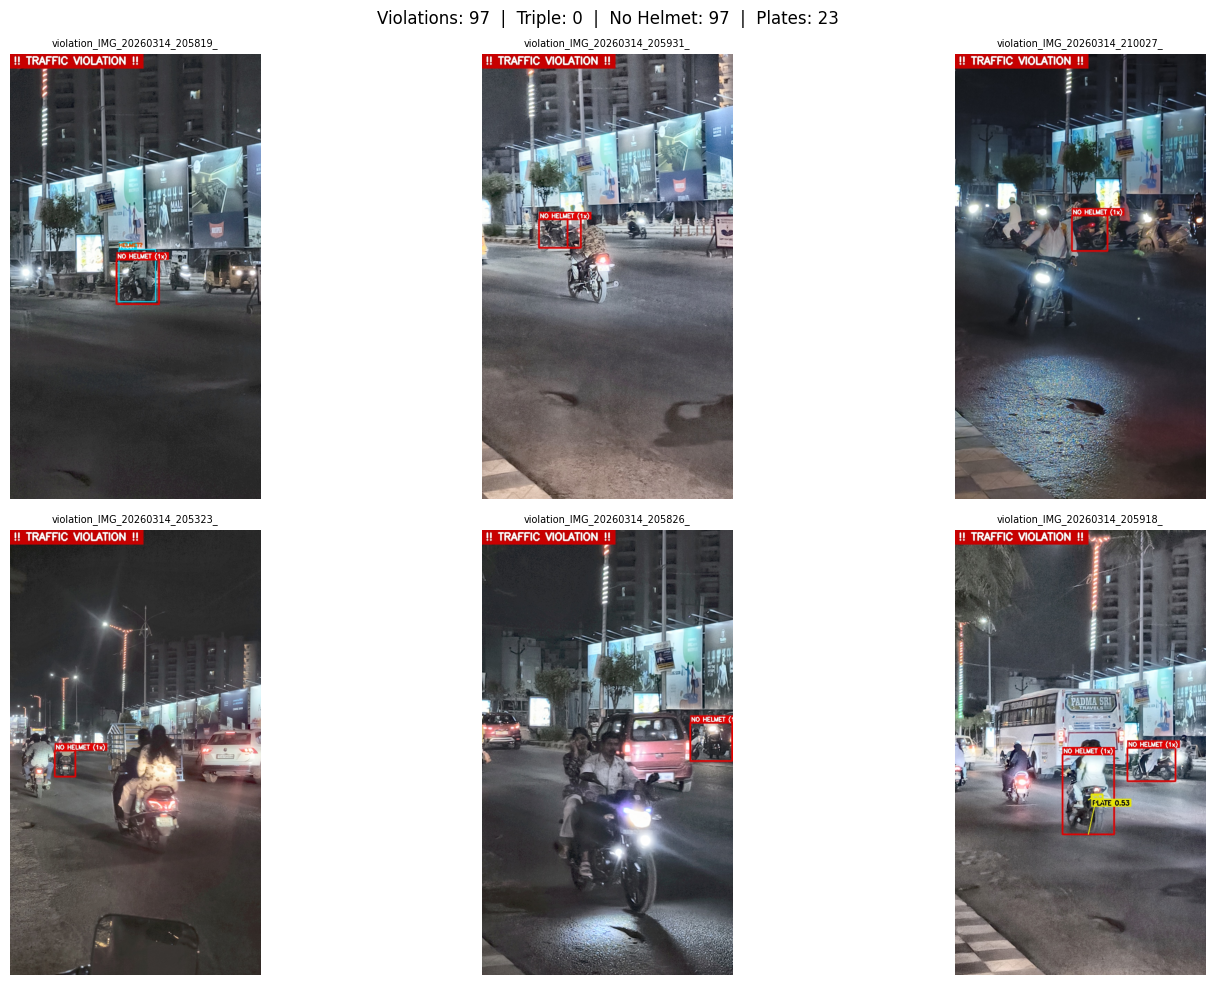

In [16]:
"""
Traffic Violation Detector — 3 Model Pipeline
Bike → Helmet2 (Bike_Rider + Helmet + No_Helmet) → Plate
"""

from google.colab import drive
drive.mount('/content/drive')

!pip install openpyxl pandas -q

import cv2
import gc
import torch
import numpy as np
import time
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
from datetime import datetime
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.utils import get_column_letter

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
CONFIG = {
    "bike_model":      "/content/drive/MyDrive/MP/trained_models/vehicle.pt",
    "helmet_model":    "/content/drive/MyDrive/MP/trained_models/helmet_2.pt",
    "plate_model":     "/content/drive/MyDrive/MP/trained_models/plate.pt",

    # helmet_2.pt class names
    "rider_class":     "Bike_Rider",
    "helmet_class":    "Helmet",
    "no_helmet_class": "No_Helmet",

    # vehicle.pt — auto-corrected from model at runtime
    "bike_class":      "Motorcycle",

    "bike_conf":       0.4,
    "helmet_conf":     0.35,
    "plate_conf":      0.25,
    "max_riders":      2,
    "min_bike_area":   4000,

    "input_folder":    "/content/drive/MyDrive/MP/night_dataset",
    "output_folder":   "/content/drive/MyDrive/MP/violation_output_3",
    "imgsz":           640,
    "max_img_size":    1280,
    "device":          "cuda" if torch.cuda.is_available() else "cpu",
}

# ─────────────────────────────────────────────
# Night Enhancement (CLAHE only)
# ─────────────────────────────────────────────
def enhance_night(img_bgr):
    lab     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l       = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(l)
    img_bgr = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    table   = np.array([(i / 255.0) ** (1 / 1.5) * 255
                        for i in range(256)]).astype("uint8")
    return cv2.LUT(img_bgr, table)

def is_dark_image(img_bgr, threshold=60):
    return np.mean(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)) < threshold

# ─────────────────────────────────────────────
# Drawing Helpers
# ─────────────────────────────────────────────
def load_and_resize(path, max_size):
    img = cv2.imread(str(path))
    if img is None:
        return None
    h, w = img.shape[:2]
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        img   = cv2.resize(img, (int(w * scale), int(h * scale)),
                           interpolation=cv2.INTER_AREA)
    return img

def clamp_box(x1, y1, x2, y2, img_w, img_h):
    return (max(0, x1), max(0, y1),
            min(img_w, x2), min(img_h, y2))

def get_cls(model, box):
    return model.names[int(box.cls[0])]

def draw_box(img, x1, y1, x2, y2, label, color, thickness=2):
    cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.55
    font_thick = 2
    (tw, th), _ = cv2.getTextSize(label, font, font_scale, font_thick)
    label_y1 = y1 - th - 8
    label_y2 = y1
    if label_y1 < 0:
        label_y1 = y1
        label_y2 = y1 + th + 8
    cv2.rectangle(img, (x1, label_y1), (x1 + tw + 6, label_y2), color, -1)
    cv2.putText(img, label, (x1 + 3, label_y2 - 4),
                font, font_scale, (255, 255, 255), font_thick)
    return img

# ─────────────────────────────────────────────
# Association Helpers
# ─────────────────────────────────────────────
def box_contains_centre(outer, inner):
    cx = (inner[0] + inner[2]) / 2
    cy = (inner[1] + inner[3]) / 2
    return outer[0] <= cx <= outer[2] and outer[1] <= cy <= outer[3]

# ─────────────────────────────────────────────
# Plate Detection
# ─────────────────────────────────────────────
def detect_plate(img_bgr, bx1, by1, bx2, by2,
                 img_w, img_h, plate_model, config):
    device = config["device"]
    imgsz  = config["imgsz"]
    bike_h = by2 - by1

    sx1 = max(0,     bx1 - int((bx2 - bx1) * 0.05))
    sy1 = by1 + int(bike_h * 0.40)
    sx2 = min(img_w, bx2 + int((bx2 - bx1) * 0.05))
    sy2 = min(img_h, by2 + int(bike_h * 0.05))

    crop = img_bgr[sy1:sy2, sx1:sx2]
    if crop.size == 0:
        return False, 0.0, None, None

    res = plate_model.predict(
        crop, conf=config["plate_conf"],
        imgsz=imgsz, verbose=False, device=device
    )[0]

    if len(res.boxes) == 0:
        enh = enhance_night(crop)
        res = plate_model.predict(
            enh, conf=config["plate_conf"] * 0.6,
            imgsz=imgsz, verbose=False, device=device
        )[0]
        if len(res.boxes) > 0:
            crop = enh

    if len(res.boxes) == 0:
        return False, 0.0, None, None

    best             = max(res.boxes, key=lambda b: float(b.conf[0]))
    px1, py1, px2, py2 = map(int, best.xyxy[0])
    plate_conf       = float(best.conf[0])

    apx1, apy1, apx2, apy2 = clamp_box(
        sx1 + px1, sy1 + py1,
        sx1 + px2, sy1 + py2,
        img_w, img_h
    )

    plate_img = img_bgr[apy1:apy2, apx1:apx2]
    if plate_img.size == 0:
        return False, 0.0, None, None

    return True, plate_conf, plate_img, (apx1, apy1, apx2, apy2)

# ─────────────────────────────────────────────
# Process single image — 3 model pipeline
# ─────────────────────────────────────────────
def process_image(img_path, bike_model, helmet_model,
                  plate_model, config):

    device = config["device"]
    imgsz  = config["imgsz"]

    img_bgr = load_and_resize(img_path, config["max_img_size"])
    if img_bgr is None:
        return None, []

    img_h, img_w = img_bgr.shape[:2]

    # Night enhancement
    if is_dark_image(img_bgr):
        img_bgr = enhance_night(img_bgr)

    output_img = img_bgr.copy()
    violations = []

    # ── Step 1: Detect bikes ─────────────────────────────────────
    bike_res = bike_model.predict(
        img_bgr, conf=config["bike_conf"],
        imgsz=imgsz, verbose=False, device=device
    )[0]

    if len(bike_res.boxes) == 0:
        return output_img, []

    # ── Step 2: Run helmet_2 on full image once ──────────────────
    helmet_res = helmet_model.predict(
        img_bgr, conf=config["helmet_conf"],
        imgsz=imgsz, verbose=False, device=device
    )[0]

    rider_boxes     = []
    helmet_boxes    = []
    no_helmet_boxes = []

    for hbox in helmet_res.boxes:
        cls  = get_cls(helmet_model, hbox)
        xyxy = tuple(map(int, hbox.xyxy[0]))
        conf = float(hbox.conf[0])
        if cls == config["rider_class"]:
            rider_boxes.append((*xyxy, conf))
        elif cls == config["helmet_class"]:
            helmet_boxes.append((*xyxy, conf))
        elif cls == config["no_helmet_class"]:
            no_helmet_boxes.append((*xyxy, conf))

    # ── Step 3: Per bike ─────────────────────────────────────────
    bike_boxes_sorted = sorted(
        bike_res.boxes,
        key=lambda b: (int(b.xyxy[0][2]) - int(b.xyxy[0][0])) *
                      (int(b.xyxy[0][3]) - int(b.xyxy[0][1])),
        reverse=True
    )

    for bike_box in bike_boxes_sorted:
        bike_cls = get_cls(bike_model, bike_box).lower()
        if config["bike_class"].lower() not in bike_cls:
            continue

        bx1, by1, bx2, by2 = map(int, bike_box.xyxy[0])
        bike_area           = (bx2 - bx1) * (by2 - by1)
        bike_conf_val       = float(bike_box.conf[0])

        if bike_area < config["min_bike_area"]:
            continue

        draw_box(output_img, bx1, by1, bx2, by2,
                 f"Bike {bike_conf_val:.2f}", (255, 140, 0))

        # Expanded bike region for association
        exp_x1 = max(0,     bx1 - int((bx2 - bx1) * 0.15))
        exp_y1 = max(0,     by1 - int((by2 - by1) * 0.25))
        exp_x2 = min(img_w, bx2 + int((bx2 - bx1) * 0.15))
        exp_y2 = min(img_h, by2 + int((by2 - by1) * 0.10))
        bike_exp = (exp_x1, exp_y1, exp_x2, exp_y2)

        # Associate riders whose centre falls inside bike region
        assoc_riders = [
            r for r in rider_boxes
            if box_contains_centre(bike_exp, r[:4])
        ]

        # Fallback: treat bike box itself as one rider
        if not assoc_riders:
            assoc_riders = [(bx1, by1, bx2, by2, bike_conf_val)]

        rider_count     = len(assoc_riders)
        helmet_count    = 0
        no_helmet_count = 0

        for (rx1, ry1, rx2, ry2, rconf) in assoc_riders:
            draw_box(output_img, rx1, ry1, rx2, ry2,
                     "Rider", (255, 220, 0))

            # Check helmet/no-helmet box in top 50% of rider box
            rider_top = (rx1, ry1, rx2, ry1 + (ry2 - ry1) // 2)

            matched_helmet    = any(
                box_contains_centre(rider_top, h[:4])
                for h in helmet_boxes
            )
            matched_no_helmet = any(
                box_contains_centre(rider_top, h[:4])
                for h in no_helmet_boxes
            )

            if matched_helmet:
                helmet_count += 1
                cv2.putText(output_img, "HELMET ✓",
                            (rx1, max(ry1 - 8, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.55, (0, 200, 0), 2)
            elif matched_no_helmet:
                no_helmet_count += 1
                cv2.putText(output_img, "NO HELMET ✗",
                            (rx1, max(ry1 - 8, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.55, (0, 0, 255), 2)
            else:
                no_helmet_count += 1
                cv2.putText(output_img, "HELMET?",
                            (rx1, max(ry1 - 8, 15)),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.50, (0, 80, 220), 2)

        # Draw Helmet / No_Helmet boxes belonging to this bike
        for (hx1, hy1, hx2, hy2, hconf) in helmet_boxes:
            if box_contains_centre(bike_exp, (hx1, hy1, hx2, hy2)):
                draw_box(output_img, hx1, hy1, hx2, hy2,
                         f"Helmet {hconf:.2f}", (0, 200, 0), thickness=2)

        for (hx1, hy1, hx2, hy2, hconf) in no_helmet_boxes:
            if box_contains_centre(bike_exp, (hx1, hy1, hx2, hy2)):
                draw_box(output_img, hx1, hy1, hx2, hy2,
                         f"No Helmet {hconf:.2f}", (0, 0, 220), thickness=2)

        # ── Violations ────────────────────────────────────────────
        violation_types = []
        if rider_count > config["max_riders"]:
            violation_types.append(f"TRIPLE RIDING ({rider_count} riders)")
        if no_helmet_count > 0:
            violation_types.append(f"NO HELMET ({no_helmet_count}x)")

        if not violation_types:
            cv2.rectangle(output_img, (bx1, by1), (bx2, by2),
                          (0, 210, 0), 2)
            continue

        violation_label = " + ".join(violation_types)
        draw_box(output_img, bx1, by1, bx2, by2,
                 violation_label, (0, 0, 230), thickness=3)

        banner = "!! TRAFFIC VIOLATION !!"
        (bw2, bh2), _ = cv2.getTextSize(
            banner, cv2.FONT_HERSHEY_SIMPLEX, 1.0, 3)
        cv2.rectangle(output_img, (0, 0),
                      (bw2 + 20, bh2 + 18), (0, 0, 200), -1)
        cv2.putText(output_img, banner, (10, bh2 + 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                    (255, 255, 255), 3)

        # ── Plate detection ───────────────────────────────────────
        plate_found, plate_conf_val, plate_img, plate_coords = detect_plate(
            img_bgr, bx1, by1, bx2, by2,
            img_w, img_h, plate_model, config
        )

        if plate_found and plate_coords:
            apx1, apy1, apx2, apy2 = plate_coords
            cv2.rectangle(output_img,
                          (apx1, apy1), (apx2, apy2),
                          (0, 230, 230), 3)
            plate_label = f"PLATE {plate_conf_val:.2f}"
            (ptw, pth), _ = cv2.getTextSize(
                plate_label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            lby1 = apy2
            lby2 = apy2 + pth + 8
            if lby2 > img_h:
                lby1 = apy1 - pth - 8
                lby2 = apy1
            cv2.rectangle(output_img,
                          (apx1, lby1), (apx1 + ptw + 6, lby2),
                          (0, 230, 230), -1)
            cv2.putText(output_img, plate_label,
                        (apx1 + 3, lby2 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (0, 0, 0), 2)
            cv2.arrowedLine(output_img,
                            ((bx1 + bx2) // 2, by2),
                            ((apx1 + apx2) // 2, apy1),
                            (0, 230, 230), 2, tipLength=0.25)

        violations.append({
            "image":       img_path.name,
            "violation":   violation_label,
            "rider_count": rider_count,
            "helmet_count": helmet_count,
            "no_helmet":   no_helmet_count,
            "plate_found": plate_found,
            "plate_conf":  round(plate_conf_val, 3),
            "plate_img":   plate_img,
            "timestamp":   datetime.now().isoformat(),
        })

    return output_img, violations

# ─────────────────────────────────────────────
# Excel Report Generator
# ─────────────────────────────────────────────
def save_excel_report(violation_log, stats, out_base, out_plates, out_images):
    excel_path = out_base / "violation_report.xlsx"

    df_summary = pd.DataFrame({
        "Metric": [
            "Total Images Processed", "Total Bikes Found",
            "Total Violations", "Triple Riding",
            "No Helmet", "Plates Captured", "Plates Missed",
        ],
        "Count": [
            stats["total"],        stats["bikes_found"],
            stats["violations"],   stats["triple_riding"],
            stats["no_helmet"],    stats["plates_found"],
            stats["plates_missed"],
        ]
    })

    df_log = pd.DataFrame(violation_log) if violation_log else pd.DataFrame()

    with pd.ExcelWriter(str(excel_path), engine="openpyxl") as writer:
        df_summary.to_excel(writer, sheet_name="Summary",    index=False)
        if not df_log.empty:
            df_log.to_excel(writer, sheet_name="Violations", index=False)

    wb  = load_workbook(str(excel_path))
    hdr = PatternFill("solid", fgColor="1F4E79")
    hf  = Font(color="FFFFFF", bold=True, size=12)

    ws_sum = wb["Summary"]
    for cell in ws_sum[1]:
        cell.fill = hdr; cell.font = hf
        cell.alignment = Alignment(horizontal="center")
    red_fill    = PatternFill("solid", fgColor="FFD7D7")
    orange_fill = PatternFill("solid", fgColor="FFF3CD")
    for row in ws_sum.iter_rows(min_row=2):
        m = str(row[0].value)
        f = red_fill if any(x in m for x in
                            ["Violation","Triple","Helmet"]) \
            else orange_fill if "Plate" in m else None
        if f:
            for cell in row: cell.fill = f
    for col in ws_sum.columns:
        ws_sum.column_dimensions[
            get_column_letter(col[0].column)
        ].width = max(len(str(c.value or "")) for c in col) + 4

    if "Violations" in wb.sheetnames:
        ws_vio = wb["Violations"]
        for w, col in zip([30,35,10,10,12,14,18,25],
                          ["A","B","C","D","E","F","G","H"]):
            ws_vio.column_dimensions[col].width = w
        for cell in ws_vio[1]:
            cell.fill = hdr; cell.font = hf
            cell.alignment = Alignment(horizontal="center")
        both_f   = PatternFill("solid", fgColor="FF9999")
        triple_f = PatternFill("solid", fgColor="FFD7D7")
        helmet_f = PatternFill("solid", fgColor="FFE8CC")
        for row in ws_vio.iter_rows(min_row=2):
            vt = str(row[1].value or "") if len(row) > 1 else ""
            f  = both_f   if ("TRIPLE" in vt and "HELMET" in vt) \
                 else triple_f if "TRIPLE" in vt \
                 else helmet_f if "HELMET" in vt else None
            if f:
                for cell in row:
                    cell.fill = f
                    cell.alignment = Alignment(horizontal="center")

    plate_imgs = list(out_plates.glob("*.jpg"))
    if plate_imgs:
        ws_p = wb.create_sheet("Plate Crops")
        for cell, title in zip(ws_p[1],
            ["Sr","Image Name","Plate Crop","Violation","Timestamp"]):
            cell.value = title; cell.fill = hdr; cell.font = hf
            cell.alignment = Alignment(horizontal="center")
        for w, col in zip([6,30,25,35,25], ["A","B","C","D","E"]):
            ws_p.column_dimensions[col].width = w
        plate_log_map = {e.get("image",""): e for e in violation_log}
        row_num = 2
        for sr, pp in enumerate(plate_imgs[:100], 1):
            ws_p.row_dimensions[row_num].height = 65
            parts     = pp.stem.replace("plate_","").rsplit("_b",1)
            orig_name = parts[0]+".jpg" if parts else ""
            le        = plate_log_map.get(orig_name, {})
            ws_p[f"A{row_num}"] = sr
            ws_p[f"B{row_num}"] = pp.name
            ws_p[f"D{row_num}"] = le.get("violation","")
            ws_p[f"E{row_num}"] = le.get("timestamp","")
            for col in ["A","B","D","E"]:
                ws_p[f"{col}{row_num}"].alignment = \
                    Alignment(horizontal="center", vertical="center")
            try:
                xi = XLImage(str(pp)); xi.width=160; xi.height=58
                ws_p.add_image(xi, f"C{row_num}")
            except Exception:
                ws_p[f"C{row_num}"] = "Image error"
            row_num += 1

    ann_imgs = list(out_images.glob("violation_*.jpg"))
    if ann_imgs:
        ws_ann = wb.create_sheet("Annotated Images")
        for cell, title in zip(ws_ann[1],
            ["Sr","Image Name","Annotated Preview","Violation"]):
            cell.value = title; cell.fill = hdr; cell.font = hf
            cell.alignment = Alignment(horizontal="center")
        for w, col in zip([6,30,40,35], ["A","B","C","D"]):
            ws_ann.column_dimensions[col].width = w
        plate_log_map2 = {e.get("image",""): e for e in violation_log}

        # Pre-generate all thumbnails BEFORE wb.save()
        tmp_map = {}
        for ann_path in ann_imgs[:50]:
            try:
                img_b = cv2.imread(str(ann_path))
                if img_b is not None:
                    h, w     = img_b.shape[:2]
                    scale    = 300 / max(h, w)
                    small    = cv2.resize(img_b,
                                         (int(w*scale), int(h*scale)))
                    tmp_path = out_images / f"_tmp_{ann_path.name}"
                    cv2.imwrite(str(tmp_path), small)
                    if tmp_path.exists() and tmp_path.stat().st_size > 0:
                        tmp_map[ann_path] = tmp_path
                    else:
                        tmp_map[ann_path] = None
                else:
                    tmp_map[ann_path] = None
            except Exception as e:
                print(f"[WARN] Thumb failed {ann_path.name}: {e}")
                tmp_map[ann_path] = None

        row_num = 2
        for sr, ann_path in enumerate(ann_imgs[:50], 1):
            ws_ann.row_dimensions[row_num].height = 120
            orig_name = ann_path.name.replace("violation_","")
            le        = plate_log_map2.get(orig_name, {})
            ws_ann[f"A{row_num}"] = sr
            ws_ann[f"B{row_num}"] = orig_name
            ws_ann[f"D{row_num}"] = le.get("violation","")
            for col in ["A","B","D"]:
                ws_ann[f"{col}{row_num}"].alignment = \
                    Alignment(horizontal="center", vertical="center")
            tp = tmp_map.get(ann_path)
            if tp:
                try:
                    xi = XLImage(str(tp)); xi.width=260; xi.height=115
                    ws_ann.add_image(xi, f"C{row_num}")
                except Exception:
                    ws_ann[f"C{row_num}"] = "Image error"
            else:
                ws_ann[f"C{row_num}"] = "Image error"
            row_num += 1

    # Save FIRST, then clean up temp files
    wb.save(str(excel_path))
    print(f"✅ Excel report saved: {excel_path}")
    for tmp in out_images.glob("_tmp_*.jpg"):
        try: tmp.unlink()
        except Exception: pass

    return excel_path

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    device = CONFIG["device"]
    print(f"[INFO] Device: {device}")
    torch.cuda.empty_cache(); gc.collect()

    out_base   = Path(CONFIG["output_folder"])
    out_images = out_base / "annotated"
    out_plates = out_base / "plates"
    out_log    = out_base / "logs"
    for d in [out_images, out_plates, out_log]:
        d.mkdir(parents=True, exist_ok=True)

    print("[INFO] Loading models...")
    bike_model   = YOLO(CONFIG["bike_model"])
    helmet_model = YOLO(CONFIG["helmet_model"])
    plate_model  = YOLO(CONFIG["plate_model"])

    print(f"\nBike   : {bike_model.names}")
    print(f"Helmet2: {helmet_model.names}")
    print(f"Plate  : {plate_model.names}\n")

    # Auto-correct bike class name casing
    for v in bike_model.names.values():
        if v.lower() == CONFIG["bike_class"].lower():
            CONFIG["bike_class"] = v; break

    # Verify helmet_2 class names
    hnames = list(helmet_model.names.values())
    for key in ["rider_class", "helmet_class", "no_helmet_class"]:
        match = next((n for n in hnames
                      if n.lower() == CONFIG[key].lower()), None)
        if match:
            CONFIG[key] = match
        else:
            print(f"[WARN] '{CONFIG[key]}' not found in helmet model: {hnames}")

    print(f"[INFO] bike='{CONFIG['bike_class']}' | "
          f"rider='{CONFIG['rider_class']}' | "
          f"helmet='{CONFIG['helmet_class']}' | "
          f"no_helmet='{CONFIG['no_helmet_class']}'")

    print("[INFO] Warming up...")
    dummy = np.zeros((640, 640, 3), dtype=np.uint8)
    for m in [bike_model, helmet_model, plate_model]:
        m.predict(dummy, imgsz=640, verbose=False, device=device)
    print("[INFO] Warmup done ✅\n")

    image_paths = sorted(
        list(Path(CONFIG["input_folder"]).glob("*.jpg")) +
        list(Path(CONFIG["input_folder"]).glob("*.png"))
    )
    print(f"[INFO] Found {len(image_paths)} images")

    stats = {
        "total": len(image_paths), "bikes_found": 0,
        "violations": 0, "triple_riding": 0,
        "no_helmet": 0, "plates_found": 0, "plates_missed": 0,
    }
    violation_log = []
    t_start = time.time()

    for idx, img_path in enumerate(tqdm(image_paths, desc="Processing")):
        try:
            output_img, violations = process_image(
                img_path, bike_model, helmet_model,
                plate_model, CONFIG
            )
        except Exception as e:
            print(f"\n[ERROR] {img_path.name}: {e}")
            import traceback; traceback.print_exc()
            continue

        if not violations:
            continue

        stats["bikes_found"] += 1
        cv2.imwrite(
            str(out_images / f"violation_{img_path.name}"),
            output_img
        )

        for v_idx, v in enumerate(violations):
            stats["violations"] += 1
            if "TRIPLE" in v["violation"]: stats["triple_riding"] += 1
            if "HELMET" in v["violation"]: stats["no_helmet"] += 1

            if v["plate_found"]:
                stats["plates_found"] += 1
                if v["plate_img"] is not None and v["plate_img"].size > 0:
                    cv2.imwrite(
                        str(out_plates /
                            f"plate_{img_path.stem}_b{v_idx}.jpg"),
                        v["plate_img"]
                    )
            else:
                stats["plates_missed"] += 1

            log_entry = {k: v[k] for k in v if k != "plate_img"}
            violation_log.append(log_entry)

        if idx % 30 == 0:
            torch.cuda.empty_cache(); gc.collect()

    with open(str(out_log / "violation_log.json"), "w") as f:
        json.dump(violation_log, f, indent=2)

    elapsed = time.time() - t_start

    excel_path = save_excel_report(
        violation_log, stats, out_base, out_plates, out_images
    )

    print(f"""
╔══════════════════════════════════════╗
  Total images     : {stats['total']}
  Total time       : {elapsed:.1f}s
  ────────────────────────────────────
  Bikes found      : {stats['bikes_found']}
  Violations       : {stats['violations']}
  Triple riding    : {stats['triple_riding']}
  No helmet        : {stats['no_helmet']}
  Plates captured  : {stats['plates_found']}
  Plates missed    : {stats['plates_missed']}
╚══════════════════════════════════════╝
""")

    from google.colab import files
    files.download(str(excel_path))

    import matplotlib.pyplot as plt
    import random

    samples = list(out_images.glob("violation_*.jpg"))
    if samples:
        picks = random.sample(samples, min(6, len(samples)))
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        for ax, p in zip(axes, picks):
            img = cv2.imread(str(p))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.set_title(p.name[:30], fontsize=7)
            ax.axis("off")
        for ax in axes[len(picks):]:
            ax.axis("off")
        plt.suptitle(
            f"Violations: {stats['violations']}  |  "
            f"Triple: {stats['triple_riding']}  |  "
            f"No Helmet: {stats['no_helmet']}  |  "
            f"Plates: {stats['plates_found']}"
        )
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No violations found.")
        print(f"Bike   : {bike_model.names}")
        print(f"Helmet2: {helmet_model.names}")